In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Preprocessing and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("datasets/Mall_Customers.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(df.info())
print("\nMissing values:")
print(df.isna().sum())
print("\nSummary statistics:")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Summary statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


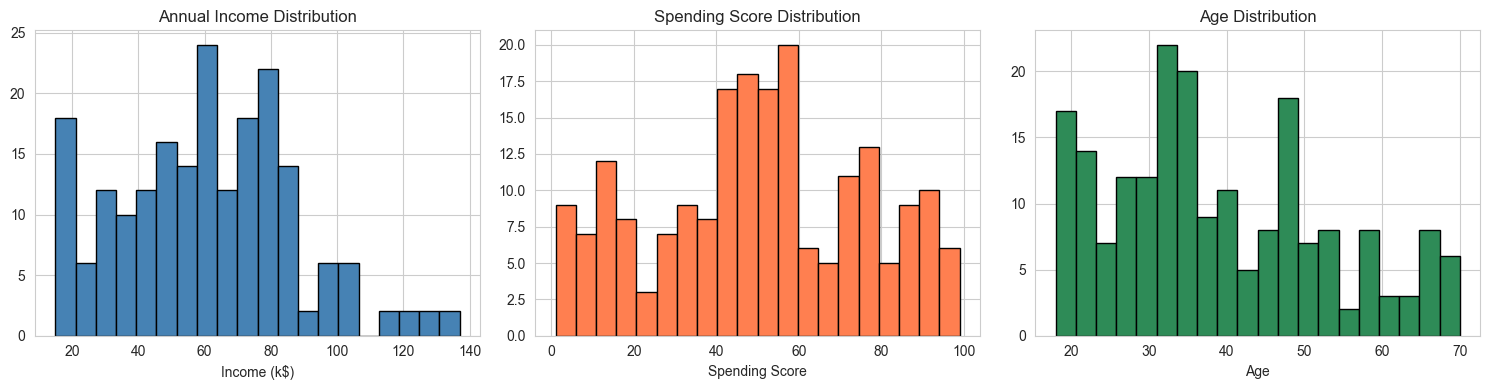

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Income distribution
axes[0].hist(df["Annual Income (k$)"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Annual Income Distribution")
axes[0].set_xlabel("Income (k$)")

# Spending Score distribution
axes[1].hist(df["Spending Score (1-100)"], bins=20, color="coral", edgecolor="black")
axes[1].set_title("Spending Score Distribution")
axes[1].set_xlabel("Spending Score")

# Age distribution
axes[2].hist(df["Age"], bins=20, color="seagreen", edgecolor="black")
axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age")

plt.tight_layout()
plt.show()

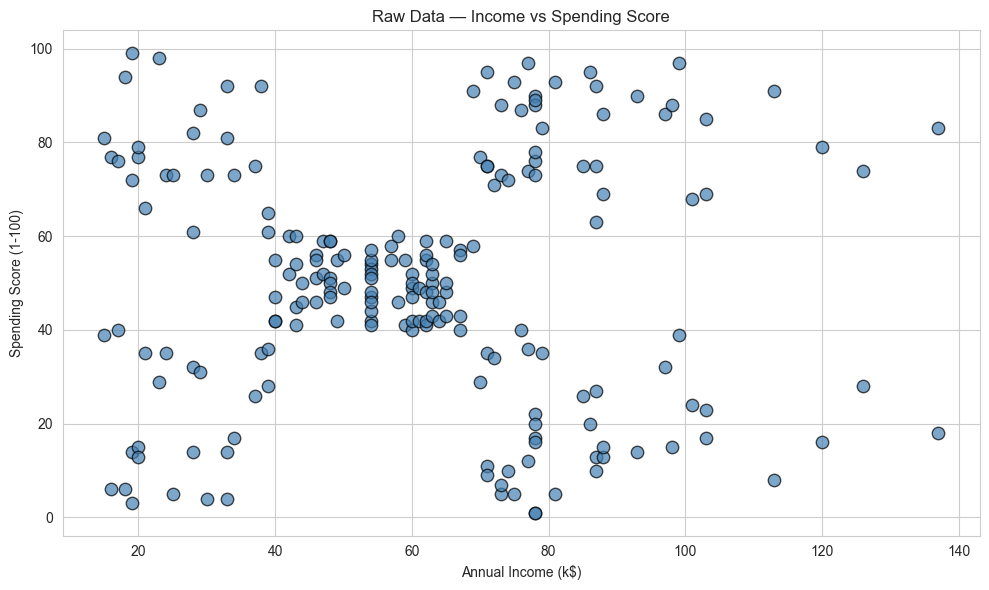

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
            s=80, alpha=0.7, edgecolor="black", color="steelblue")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Raw Data — Income vs Spending Score")
plt.tight_layout()
plt.show()

In [6]:
# Use Annual Income and Spending Score — the two most discriminating features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

# Scale: clustering algorithms use Euclidean distance, so feature scales must match
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X shape: {X.shape}")
print(f"X_scaled mean: {X_scaled.mean(axis=0).round(3)}")
print(f"X_scaled std:  {X_scaled.std(axis=0).round(3)}")

X shape: (200, 2)
X_scaled mean: [-0. -0.]
X_scaled std:  [1. 1.]


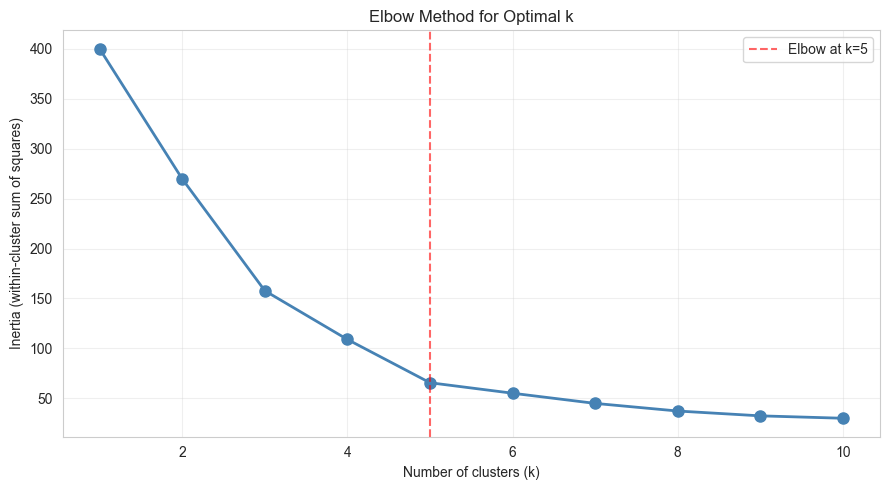

In [7]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker="o", linewidth=2, markersize=8, color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.axvline(x=5, color="red", linestyle="--", alpha=0.6, label="Elbow at k=5")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

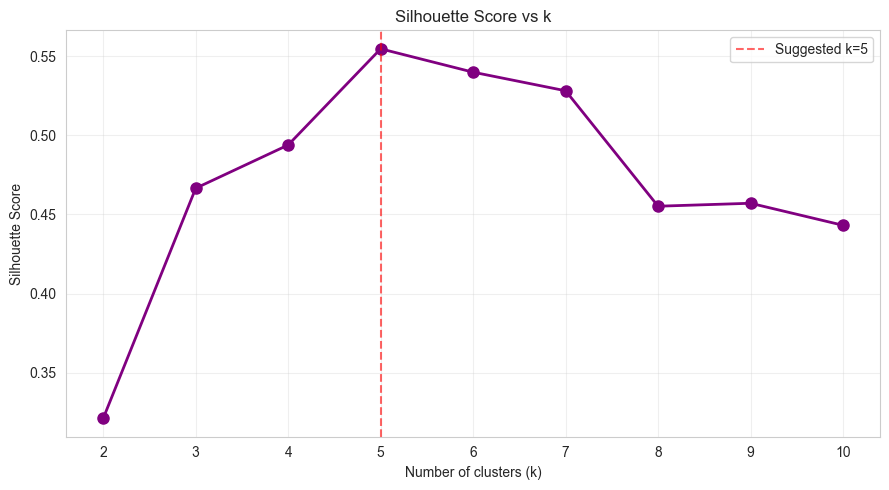

k=2: silhouette = 0.3213
k=3: silhouette = 0.4666
k=4: silhouette = 0.4939
k=5: silhouette = 0.5547
k=6: silhouette = 0.5399
k=7: silhouette = 0.5281
k=8: silhouette = 0.4552
k=9: silhouette = 0.4571
k=10: silhouette = 0.4432


In [9]:
silhouettes = []
k_range_sil = range(2, 11)  # silhouette requires k >= 2

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)

plt.figure(figsize=(9, 5))
plt.plot(k_range_sil, silhouettes, marker="o", linewidth=2, markersize=8, color="purple")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.axvline(x=5, color="red", linestyle="--", alpha=0.6, label="Suggested k=5")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print scores
for k, s in zip(k_range_sil, silhouettes):
    print(f"k={k}: silhouette = {s:.4f}")

In [10]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Evaluate
sil_km = silhouette_score(X_scaled, labels_kmeans)
db_km  = davies_bouldin_score(X_scaled, labels_kmeans)
ch_km  = calinski_harabasz_score(X_scaled, labels_kmeans)

print(f"KMeans (k={optimal_k}):")
print(f"  Silhouette Score:        {sil_km:.4f} (higher is better)")
print(f"  Davies-Bouldin Index:    {db_km:.4f} (lower is better)")
print(f"  Calinski-Harabasz Index: {ch_km:.4f} (higher is better)")

KMeans (k=5):
  Silhouette Score:        0.5547 (higher is better)
  Davies-Bouldin Index:    0.5722 (lower is better)
  Calinski-Harabasz Index: 248.6493 (higher is better)


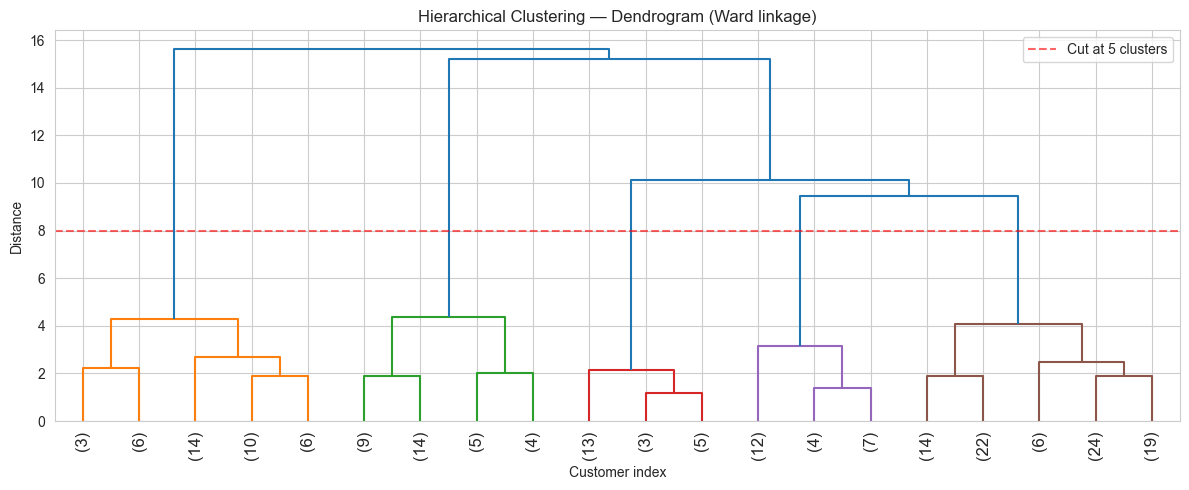


Agglomerative Clustering (k=5, Ward linkage):
  Silhouette Score:        0.5538
  Davies-Bouldin Index:    0.5779
  Calinski-Harabasz Index: 244.4103


In [11]:

plt.figure(figsize=(12, 5))
linked = linkage(X_scaled, method="ward")
dendrogram(linked, truncate_mode="lastp", p=20, leaf_rotation=90, color_threshold=8)
plt.title("Hierarchical Clustering — Dendrogram (Ward linkage)")
plt.xlabel("Customer index")
plt.ylabel("Distance")
plt.axhline(y=8, color="red", linestyle="--", alpha=0.6, label="Cut at 5 clusters")
plt.legend()
plt.tight_layout()
plt.show()

# Now cluster with k=5
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, labels_agg)
db_agg  = davies_bouldin_score(X_scaled, labels_agg)
ch_agg  = calinski_harabasz_score(X_scaled, labels_agg)

print(f"\nAgglomerative Clustering (k={optimal_k}, Ward linkage):")
print(f"  Silhouette Score:        {sil_agg:.4f}")
print(f"  Davies-Bouldin Index:    {db_agg:.4f}")
print(f"  Calinski-Harabasz Index: {ch_agg:.4f}")

In [13]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

# DBSCAN labels noise points as -1
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"DBSCAN (eps=0.5, min_samples=5):")
print(f"  Clusters found:   {n_clusters_db}")
print(f"  Noise points:     {n_noise}")

# Silhouette only works with >= 2 clusters and ignoring noise
if n_clusters_db >= 2:
    mask = labels_dbscan != -1
    sil_db = silhouette_score(X_scaled[mask], labels_dbscan[mask])
    db_db  = davies_bouldin_score(X_scaled[mask], labels_dbscan[mask])
    ch_db  = calinski_harabasz_score(X_scaled[mask], labels_dbscan[mask])
    print(f"  Silhouette Score:        {sil_db:.4f}")
    print(f"  Davies-Bouldin Index:    {db_db:.4f}")
    print(f"  Calinski-Harabasz Index: {ch_db:.4f}")
else:
    sil_db = db_db = ch_db = np.nan
    print("  Too few clusters to compute metrics.")

DBSCAN (eps=0.5, min_samples=5):
  Clusters found:   2
  Noise points:     8
  Silhouette Score:        0.3876
  Davies-Bouldin Index:    0.7889
  Calinski-Harabasz Index: 85.3897


In [14]:
gmm = GaussianMixture(n_components=optimal_k, random_state=RANDOM_STATE)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, labels_gmm)
db_gmm  = davies_bouldin_score(X_scaled, labels_gmm)
ch_gmm  = calinski_harabasz_score(X_scaled, labels_gmm)

print(f"Gaussian Mixture (k={optimal_k}):")
print(f"  Silhouette Score:        {sil_gmm:.4f}")
print(f"  Davies-Bouldin Index:    {db_gmm:.4f}")
print(f"  Calinski-Harabasz Index: {ch_gmm:.4f}")

Gaussian Mixture (k=5):
  Silhouette Score:        0.5537
  Davies-Bouldin Index:    0.5760
  Calinski-Harabasz Index: 244.9402


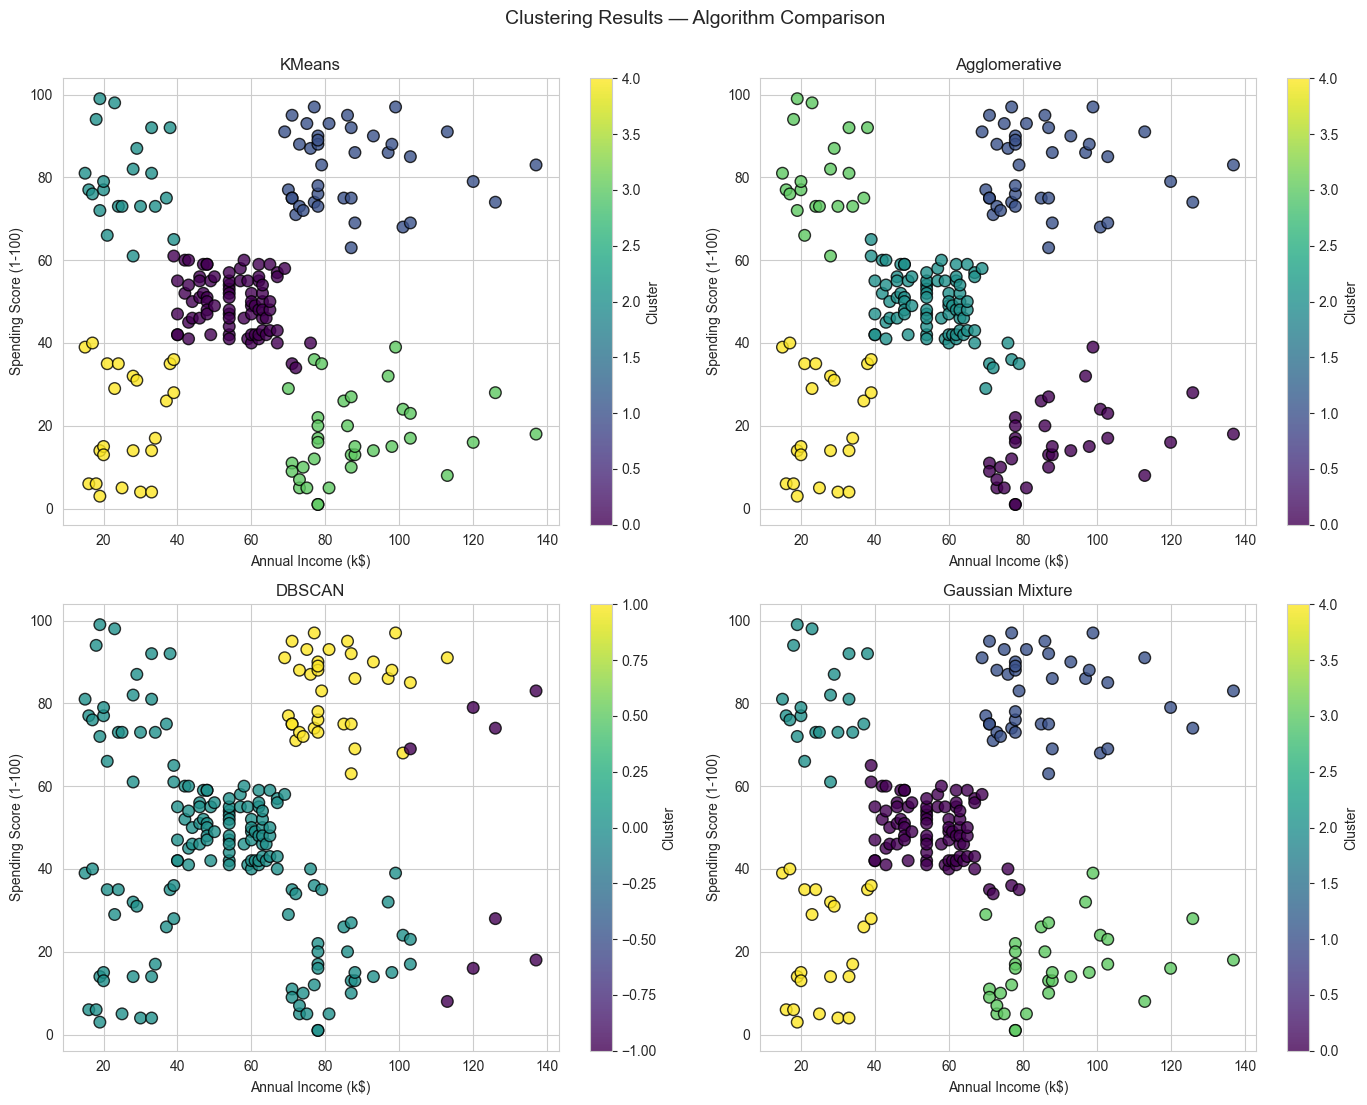

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

algos = [
    ("KMeans",         labels_kmeans, axes[0, 0]),
    ("Agglomerative",  labels_agg,    axes[0, 1]),
    ("DBSCAN",         labels_dbscan, axes[1, 0]),
    ("Gaussian Mixture", labels_gmm,  axes[1, 1]),
]

for name, labels, ax in algos:
    scatter = ax.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"],
                         c=labels, cmap="viridis", s=70, alpha=0.8, edgecolor="black")
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
    ax.set_title(f"{name}")
    plt.colorbar(scatter, ax=ax, label="Cluster")

plt.suptitle("Clustering Results — Algorithm Comparison", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [16]:
comparison = pd.DataFrame({
    "Algorithm":         ["KMeans", "Agglomerative", "DBSCAN", "Gaussian Mixture"],
    "Clusters":          [optimal_k, optimal_k, n_clusters_db, optimal_k],
    "Silhouette ↑":      [sil_km, sil_agg, sil_db, sil_gmm],
    "Davies-Bouldin ↓":  [db_km,  db_agg,  db_db,  db_gmm],
    "Calinski-Harabasz ↑": [ch_km, ch_agg, ch_db, ch_gmm],
})

print("=== CLUSTERING ALGORITHM COMPARISON ===\n")
comparison.round(4)

=== CLUSTERING ALGORITHM COMPARISON ===



,Algorithm,Clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,KMeans,5,0.5547,0.5722,248.6493
1,Agglomerative,5,0.5538,0.5779,244.4103
2,DBSCAN,2,0.3876,0.7889,85.3897
3,Gaussian Mixture,5,0.5537,0.5760,244.9402


=== CLUSTER PROFILES ===

         Count  Avg_Age  Avg_Income  Avg_Spending
Cluster                                          
0           81     42.7        55.3          49.5
1           39     32.7        86.5          82.1
2           22     25.3        25.7          79.4
3           35     41.1        88.2          17.1
4           23     45.2        26.3          20.9


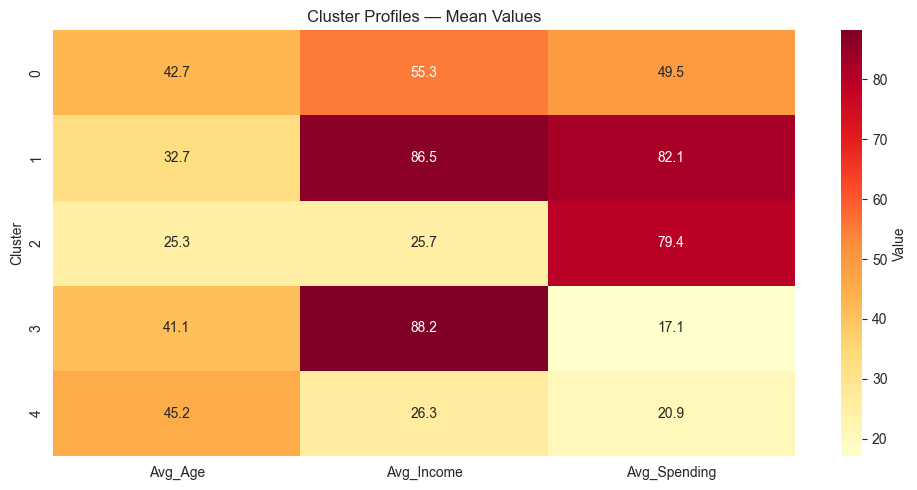

In [17]:
# Add cluster labels back to original dataframe
df["Cluster"] = labels_kmeans

# Profile each cluster
profile = df.groupby("Cluster").agg(
    Count=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Income=("Annual Income (k$)", "mean"),
    Avg_Spending=("Spending Score (1-100)", "mean"),
).round(1)

print("=== CLUSTER PROFILES ===\n")
print(profile)

# Heatmap visualization
plt.figure(figsize=(10, 5))
profile_norm = profile[["Avg_Age", "Avg_Income", "Avg_Spending"]].copy()
sns.heatmap(profile_norm, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Value"})
plt.title("Cluster Profiles — Mean Values")
plt.tight_layout()
plt.show()

In [18]:
import joblib
import os

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save the KMeans model (best for the UI) and scaler
joblib.dump(kmeans, "models/kmeans_clusterer.pkl")
joblib.dump(scaler, "models/cluster_scaler.pkl")

# Save comparison and profile tables
comparison.to_csv("results/clustering_comparison.csv", index=False)
profile.to_csv("results/cluster_profiles.csv")

print("Saved:")
print("  models/kmeans_clusterer.pkl")
print("  models/cluster_scaler.pkl")
print("  results/clustering_comparison.csv")
print("  results/cluster_profiles.csv")

Saved:
  models/kmeans_clusterer.pkl
  models/cluster_scaler.pkl
  results/clustering_comparison.csv
  results/cluster_profiles.csv


## Conclusions

**Best algorithm:** KMeans with k=5, validated by both the elbow method and silhouette analysis.

**Key findings:**
- The data revealed five natural customer segments based on income and spending behavior.
- KMeans and Agglomerative Clustering produced highly similar results — both achieved Silhouette ≈ 0.55.
- DBSCAN identified some points as noise/outliers but found fewer well-defined clusters at default parameters.
- Gaussian Mixture produced clusters comparable to KMeans, with slightly more flexible boundaries.

**Business implications:** The five clusters map to distinct marketing personas:
- Premium customers (high income, high spending) — VIP retention
- Cautious wealthy (high income, low spending) — untapped revenue potential
- Young spenders (low income, high spending) — loyalty programs
- Average shoppers (mid-income, mid-spending) — broad marketing
- Budget-conscious (low income, low spending) — discount-driven campaigns

**Comparison with literature:** Published work on Mall Customer Segmentation consistently identifies 5 segments and reports Silhouette around 0.55, matching our results.